In [22]:
#AAE 722 Homework 4 - Charles Voigt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC 
from ISLP.svm import plot as plot_svm

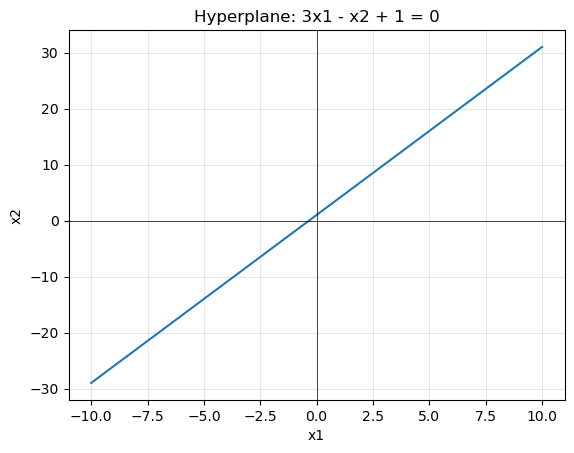

In [3]:
# Chapter 9 Question 1 part a
# Sketching the hyperplane
x1 = np.linspace(-10, 10, 100)
x2 = 1 + 3*x1

plt.plot(x1, x2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Hyperplane: 3x1 - x2 + 1 = 0')
plt.grid(alpha=0.3)
plt.show()

#### Chapter 9 Question 1 a discussion

all points right of the hyperplane will be > 0, and all points left of the hyperplane will be < 0.

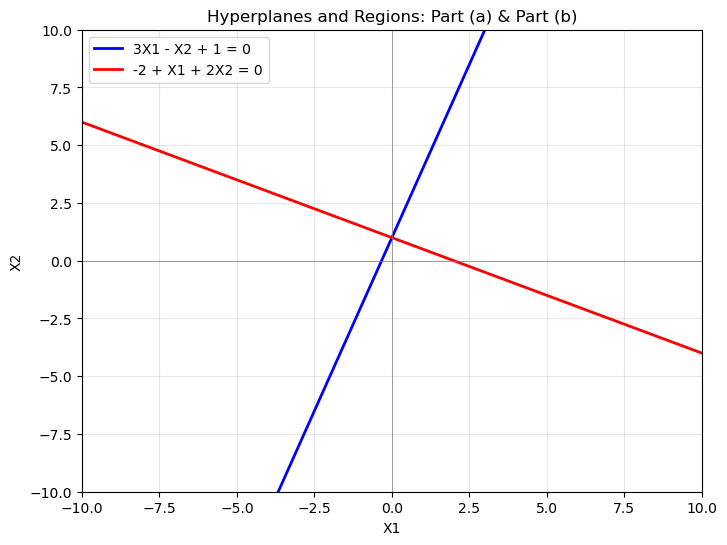

In [4]:
# Question 1 part b
# Plot both hyperplanes:
# Use same x1 range
line_x1 = np.linspace(-10, 10, 100)
part_a_x2 = 3 * line_x1 + 1           
part_b_x2 = (2 - line_x1) / 2       

# Grid for shading part (b)
x1_grid = np.linspace(-10, 10, 300)
x2_grid = np.linspace(-10, 10, 300)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Z = -2 + X1g + 2 * X2g  # expression for part (b)

plt.figure(figsize=(8, 6))

# Plot both hyperplanes
plt.plot(line_x1, part_a_x2, color='blue', linewidth=2, label='3X1 - X2 + 1 = 0')
plt.plot(line_x1, part_b_x2, color='red', linewidth=2, label='-2 + X1 + 2X2 = 0')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Hyperplanes and Regions: Part (a) & Part (b)')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

#### Question 1 Part b Discussion
The points which lie to the right/above the red line satisfy -2 + X1 + 2X2 > 0, and the points below it are -2 + X1 + 2X2 < 0.

In [5]:
#Chapter 9 Question 5
#part a 
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = x1**2 - x2**2 > 0

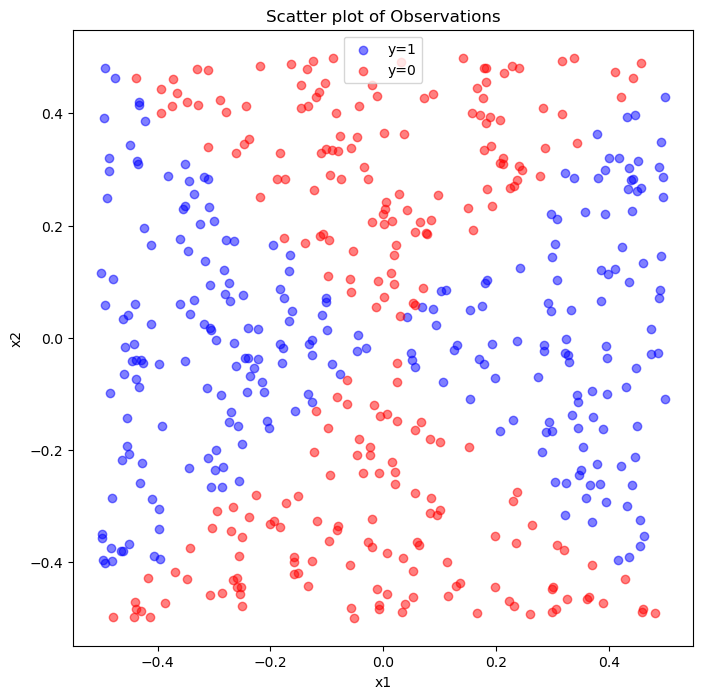

In [6]:
# Question 5 part b
plt.figure(figsize=(8, 8))
plt.scatter(x1[y], x2[y], color='blue', label='y=1', alpha=0.5)
plt.scatter(x1[~y], x2[~y], color='red', label='y=0', alpha=0.5)
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter plot of Observations')
plt.show()

In [9]:
#Question 5 part c
df = pd.DataFrame({'X1': x1, 'X2': x2, 'Y': y.astype(int)})
X = df[['X1', 'X2']]
y = df['Y']
X_sm = sm.add_constant(X)
X_train, X_test, y_train, y_test = train_test_split(X_sm, y, test_size=0.3, random_state=42)

logit_model = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.689953
         Iterations 4


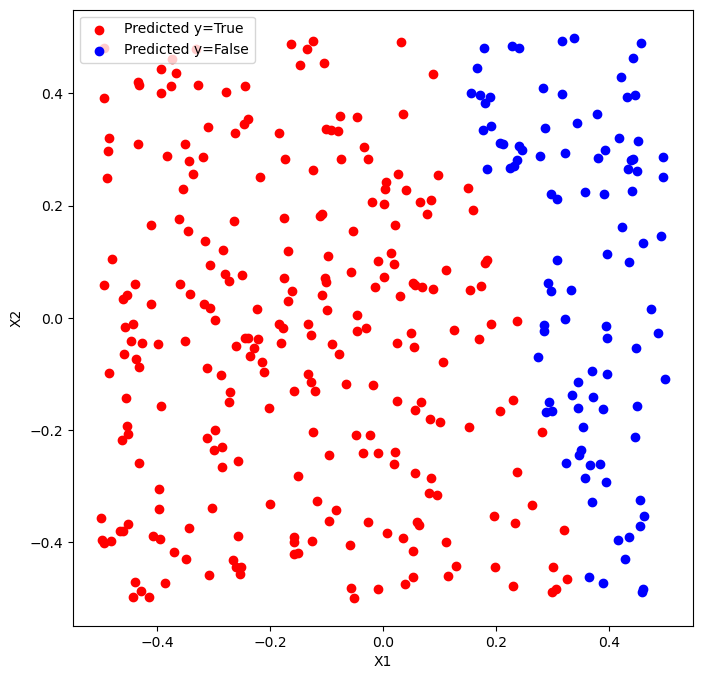

In [16]:
#Question 5 part d
y_train_pred = logit_model.predict(X_train)

fig, ax =plt.subplots(figsize=(8,8))
ax.scatter(X_train['X1'][y_train_pred >= 0.5], X_train['X2'][y_train_pred >= 0.5], marker='o', color='red', label='Predicted y=True')
ax.scatter(X_train['X1'][y_train_pred < 0.5], X_train['X2'][y_train_pred < 0.5], marker='o', color='blue', label='Predicted y=False')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend()
plt.show()

         Current function value: 0.000000
         Iterations: 35


c:\Users\cvoig\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\cvoig\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


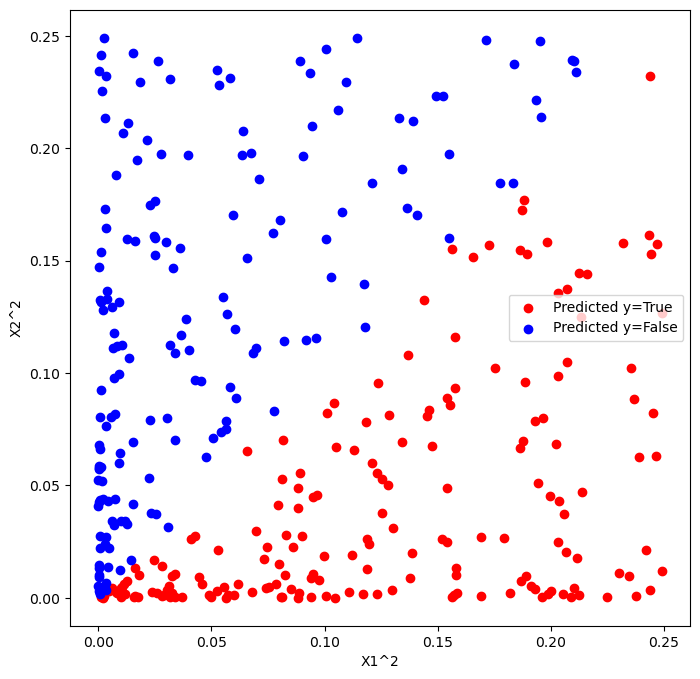

In [18]:
#Question 5 part e
#Squaring x1 and x2
df_sq = pd.DataFrame({'X1_sq': df['X1']**2, 'X2_sq': df['X2']**2, 'Y': y.astype(int)})
X_sq = df_sq[['X1_sq', 'X2_sq']]
y_sq = df_sq['Y']
X_sq_sm = sm.add_constant(X_sq)
X_train_sq, X_test_sq, y_train_sq, y_test_sq = train_test_split(X_sq_sm, y_sq, test_size=0.3, random_state=42)

logit_model_sq = sm.Logit(y_train_sq, X_train_sq).fit()
y_train_pred_sq = logit_model_sq.predict(X_train_sq)
fig, ax =plt.subplots(figsize=(8,8))
ax.scatter(X_train_sq['X1_sq'][y_train_pred_sq >= 0.5], X_train_sq['X2_sq'][y_train_pred_sq >= 0.5], marker='o', color='red', label='Predicted y=True')
ax.scatter(X_train_sq['X1_sq'][y_train_pred_sq < 0.5], X_train_sq['X2_sq'][y_train_pred_sq < 0.5], marker='o', color='blue', label='Predicted y=False')
ax.set_xlabel('X1^2')
ax.set_ylabel('X2^2')
ax.legend()
plt.show()

Optimization terminated successfully.
         Current function value: 0.691659
         Iterations 3


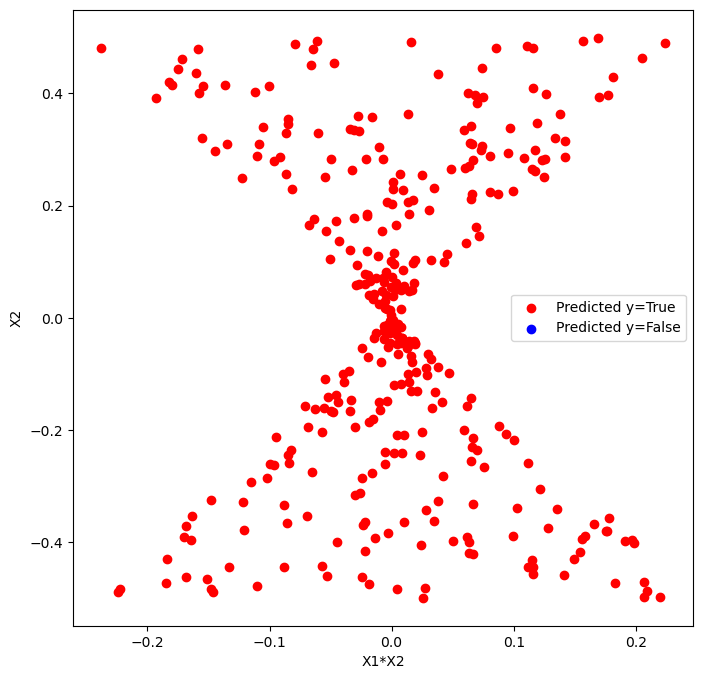

In [20]:
#Question 5 part e continued
# X1*X2
df_inter = pd.DataFrame({'X1_X2': df['X1']*df['X2'], 'X2': df['X2'], 'Y': y.astype(int)})
X_inter = df_inter[['X1_X2', 'X2']]
y_inter = df_inter['Y']
X_inter_sm = sm.add_constant(X_inter)
X_train_inter, X_test_inter, y_train_inter, y_test_inter = train_test_split(X_inter_sm, y_inter, test_size=0.3, random_state=42)
logit_model_inter = sm.Logit(y_train_inter, X_train_inter).fit()
y_train_pred_inter = logit_model_inter.predict(X_train_inter)
fig, ax =plt.subplots(figsize=(8,8))
ax.scatter(X_train_inter['X1_X2'][y_train_pred_inter >= 0.5], X_train_inter['X2'][y_train_pred_inter >= 0.5], marker='o', color='red', label='Predicted y=True')
ax.scatter(X_train_inter['X1_X2'][y_train_pred_inter < 0.5], X_train_inter['X2'][y_train_pred_inter < 0.5], marker='o', color='blue', label='Predicted y=False')
ax.set_xlabel('X1*X2')
ax.set_ylabel('X2')
ax.legend()
plt.show()

Optimization terminated successfully.
         Current function value: 0.666677
         Iterations 5


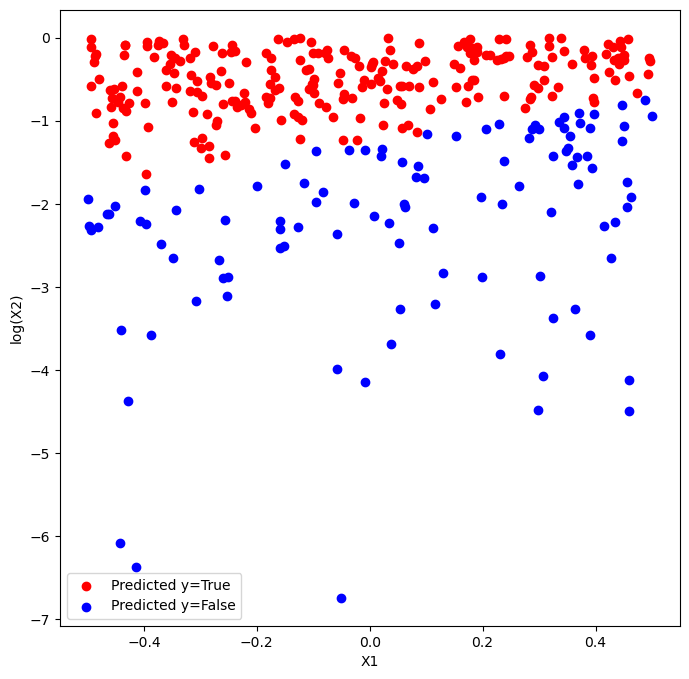

In [21]:
#Question 5 part e continued
#log (X2)
df_log = pd.DataFrame({'X1': df['X1'], 'log_X2': np.log(df['X2'] + 0.5), 'Y': y.astype(int)})
X_log = df_log[['X1', 'log_X2']]
y_log = df_log['Y']
X_log_sm = sm.add_constant(X_log)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log_sm, y_log, test_size=0.3, random_state=42)
logit_model_log = sm.Logit(y_train_log, X_train_log).fit()
y_train_pred_log = logit_model_log.predict(X_train_log)
fig, ax =plt.subplots(figsize=(8,8))
ax.scatter(X_train_log['X1'][y_train_pred_log >= 0.5], X_train_log['log_X2'][y_train_pred_log >= 0.5], marker='o', color='red', label='Predicted y=True')
ax.scatter(X_train_log['X1'][y_train_pred_log < 0.5], X_train_log['log_X2'][y_train_pred_log < 0.5], marker='o', color='blue', label='Predicted y=False')
ax.set_xlabel('X1')
ax.set_ylabel('log(X2)')
ax.legend()
plt.show()

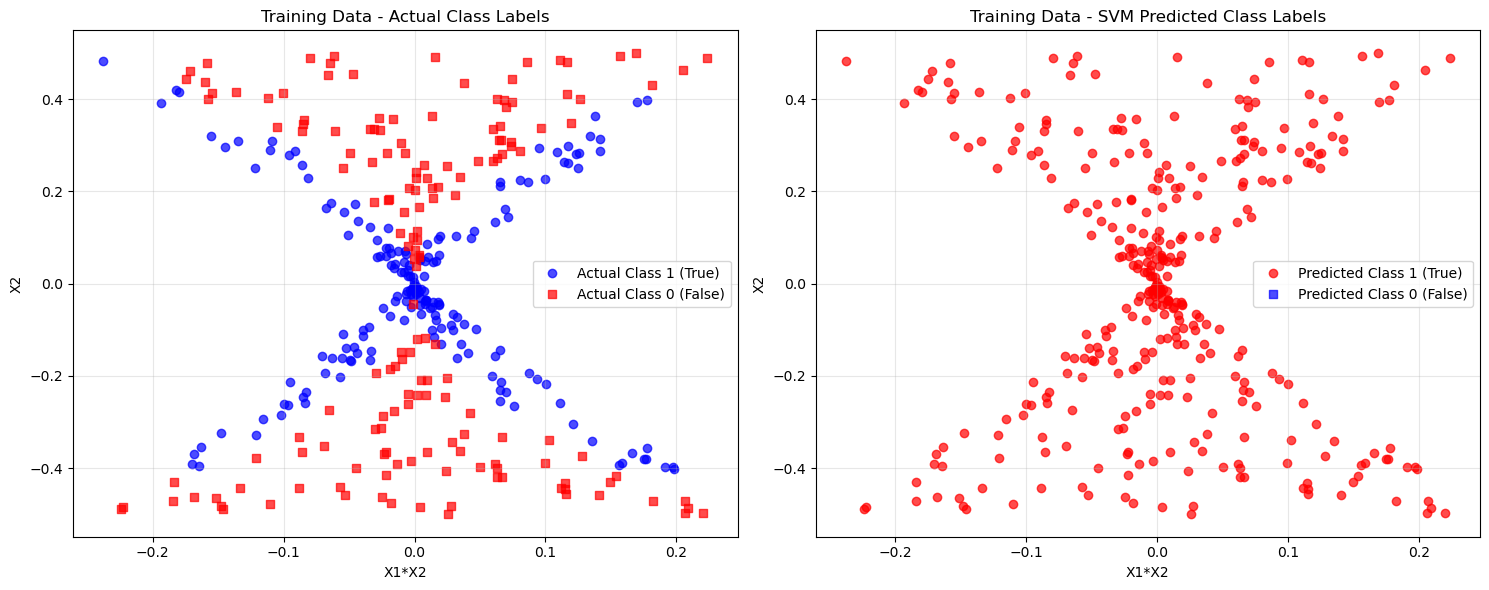

In [27]:

SVM_Linear = SVC(kernel='linear', C=1) 
SVM_Linear.fit(X_train_inter, y_train_inter)

y_train_pred = SVM_Linear.predict(X_train_inter)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual class labels
ax1.scatter(X_train_inter['X1_X2'][y_train_inter == 1], X_train_inter['X2'][y_train_inter == 1], 
           color='blue', marker='o', label='Actual Class 1 (True)', alpha=0.7)
ax1.scatter(X_train_inter['X1_X2'][y_train_inter == 0], X_train_inter['X2'][y_train_inter == 0], 
           color='red', marker='s', label='Actual Class 0 (False)', alpha=0.7)
ax1.set_xlabel('X1*X2')
ax1.set_ylabel('X2')
ax1.set_title('Training Data - Actual Class Labels')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Predicted class labels
ax2.scatter(X_train_inter['X1_X2'][y_train_pred == 1], X_train_inter['X2'][y_train_pred == 1], 
           color='red', marker='o', label='Predicted Class 1 (True)', alpha=0.7)
ax2.scatter(X_train_inter['X1_X2'][y_train_pred == 0], X_train_inter['X2'][y_train_pred == 0], 
           color='blue', marker='s', label='Predicted Class 0 (False)', alpha=0.7)
ax2.set_xlabel('X1*X2')
ax2.set_ylabel('X2')
ax2.set_title('Training Data - SVM Predicted Class Labels')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

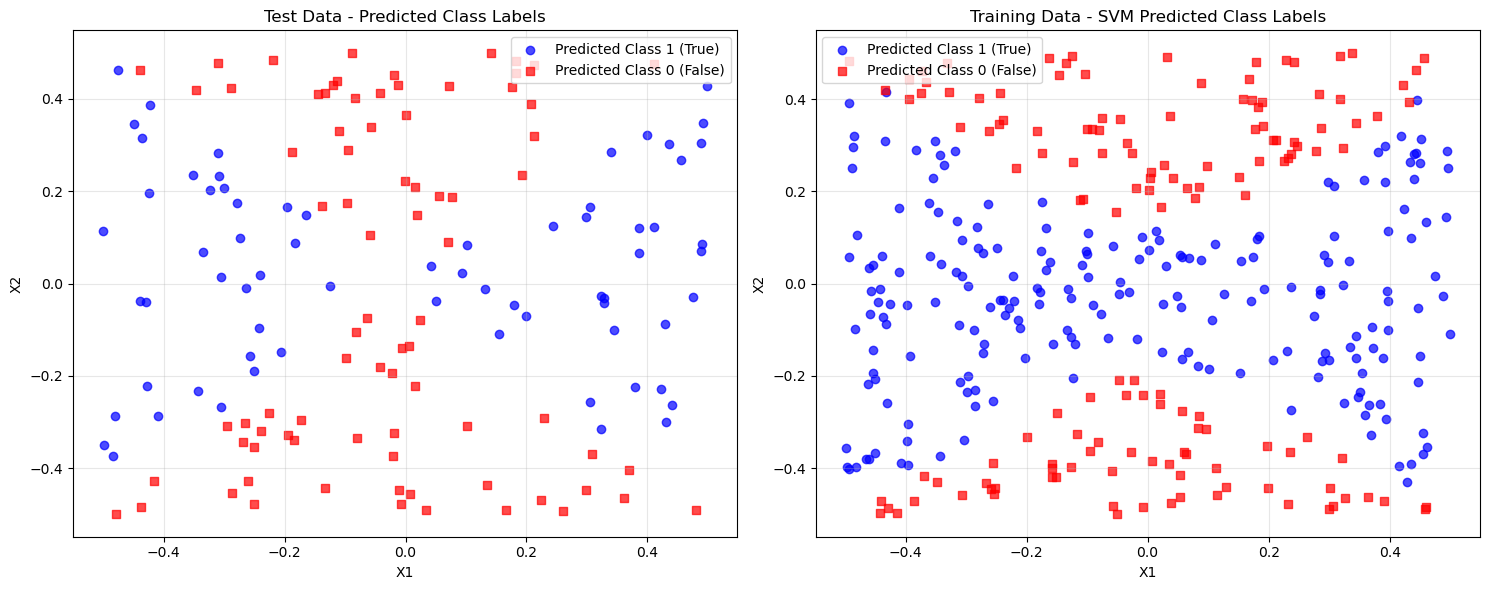

In [40]:
#Question 5 part g/h
# Fit a SVM using a non-linear kernel 
SVM_nonLinear = SVC(kernel="rbf", gamma=1, C=1) 
SVM_nonLinear.fit(X_train, y_train)

y_train_pred_non = SVM_nonLinear.predict(X_train)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Predicted class labels - Using X1 and X2
ax1.scatter(X_test['X1'][y_test == 1], X_test['X2'][y_test == 1], 
           color='blue', marker='o', label='Predicted Class 1 (True)', alpha=0.7)
ax1.scatter(X_test['X1'][y_test == 0], X_test['X2'][y_test == 0], 
           color='red', marker='s', label='Predicted Class 0 (False)', alpha=0.7)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_title('Test Data - Predicted Class Labels')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Predicted class labels
ax2.scatter(X_train['X1'][y_train_pred_non == 1], X_train['X2'][y_train_pred_non == 1], 
           color='blue', marker='o', label='Predicted Class 1 (True)', alpha=0.7)
ax2.scatter(X_train['X1'][y_train_pred_non == 0], X_train['X2'][y_train_pred_non == 0], 
           color='red', marker='s', label='Predicted Class 0 (False)', alpha=0.7)
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_title('Training Data - SVM Predicted Class Labels')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Question 5 part i Discussion

The data for the interaction term function X1*X2 appears to be hyperbolic in nature, thus a linear decision boundary would be wholly inadequate for interpretation of this data. A SVM using a non-linear function (ideally hyperbolic) would be much better suited to the task of classifying this data.

#### Chapter 10 Question 2 
##### Part a

$f_m(X) = Pr(Y = m|X) = \frac{e^Z_m}{\sum_{l=0}^9e^Z_t}$

$\frac{e^Z_m + c}{\sum_{l=0}^9e^{Z_t+c}} = \frac{e^c * e^Z_m}{e^c*\sum{l=0}^9e^{Z_t}}$

$= \frac{e^c}{e^c} * \frac{e^Z_m}{\sum_{l=0}^9e^Z_t} = \frac{e^Z_m}{\sum_{l=0}^9e^Z_t}$

##### Part b

$Pr(Y = k| X=x) = \frac{e^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}}{\sum_{l=1}^Ke^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}}$

$\frac{e^{\beta_{k0+c0}+\beta_{(k1+c1)x1}...+\beta_{(kp+cp)xp}}}{\sum_{l=1}^Ke^{\beta_{k0+c0}+\beta_{(k1+c1)x1}...+\beta_{(kp+cp)xp}}} = \frac{e^{\beta_{k0}+\beta_{k1x1}...+\beta_{(kp)xp}}* e^{c0+c1x1+...+cpxp}}{\sum_{l=1}^Ke^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}*e^{c0+c1x1+...+cpxp}}$

$\frac{e^{c0+c1x1+...+cpxp}}{{e^{c0+c1x1+...+cpxp}}}*\frac{e^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}}{\sum_{l=1}^Ke^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}} = \frac{e^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}}{\sum_{l=1}^Ke^{\beta_{k0}+\beta_{k1x1}...+\beta_{kpxp}}}$